In [1]:
import pandas as pd
import numpy as np
import os

# Load dataset
csv_path = os.path.join("..", "data", "processed", "multi_ticker_options_clean.csv")
df = pd.read_csv(csv_path)

# Create binary label — customize later!
df["label"] = (df["lastPrice"] > df["bid"]).astype(int)

# Features and target
X = df.drop("label", axis=1)
y = df["label"]

print("✅ Data and target prepared. Shape:", X.shape)



✅ Data and target prepared. Shape: (1869, 20)


In [2]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Keep only numeric columns for scaling and modeling
X_numeric = X.select_dtypes(include=[np.number])

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# SMOTE to balance classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("✅ Scaling and SMOTE complete. New shape:", X_resampled.shape)


✅ Scaling and SMOTE complete. New shape: (2314, 12)


In [3]:
import joblib
import json

# Load model
best_lgb = joblib.load("models/lightgbm_top15_model.pkl")

# Load top features
with open("models/top_15_features.json", "r") as f:
    top_features_15 = json.load(f)

print("✅ Model and features loaded.")


✅ Model and features loaded.


In [4]:
import pandas as pd
import shap
import numpy as np
import json

# Rebuild DataFrame from scaled X
X_df = pd.DataFrame(X_scaled, columns=X_numeric.columns)

# Explain the LightGBM model
explainer = shap.Explainer(best_lgb)
shap_values = explainer(X_df)

# Get top 15 features
shap_importances = pd.DataFrame({
    "feature": X_df.columns,
    "importance": np.abs(shap_values.values).mean(axis=0)
}).sort_values(by="importance", ascending=False)

top_features_15 = shap_importances.head(15)["feature"].tolist()

# Save to file
with open("models/top_15_features_v1.json", "w") as f:
    json.dump(top_features_15, f)

print("✅ Top 15 SHAP features saved:", top_features_15)


C:\Users\msuma\Desktop\options-trading-bot\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Top 15 SHAP features saved: ['strike', 'percentChange', 'lastPrice', 'days_to_expiry', 'impliedVolatility', 'moneyness', 'bid', 'volume', 'openInterest', 'change', 'spot_price', 'ask']


In [5]:
print("📊 Data shape:", df.shape)
print("\n🔢 Numeric Summary:")
print(df.describe())



📊 Data shape: (1869, 21)

🔢 Numeric Summary:
            strike    lastPrice          bid          ask       change  \
count  1869.000000  1869.000000  1869.000000  1869.000000  1869.000000   
mean    457.989032    39.879979    41.198299    42.512814     0.412124   
std     152.948112    56.425917    57.931971    58.733654     4.110305   
min      50.000000     0.010000     0.000000     0.000000   -33.459990   
25%     355.000000     0.190000     0.190000     0.250000    -0.070000   
50%     497.500000    15.090000    14.800000    16.450000     0.000000   
75%     567.000000    57.720000    61.000000    63.580000     0.049999   
max     960.000000   318.110000   314.650000   318.400000    56.240005   

       percentChange         volume  openInterest  impliedVolatility  \
count    1869.000000    1869.000000   1869.000000        1869.000000   
mean       -2.627796    1406.191011   1562.389513           0.696462   
std        21.090170    6534.896989   4226.751811           0.589378   


C:\Users\msuma\Desktop\options-trading-bot\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


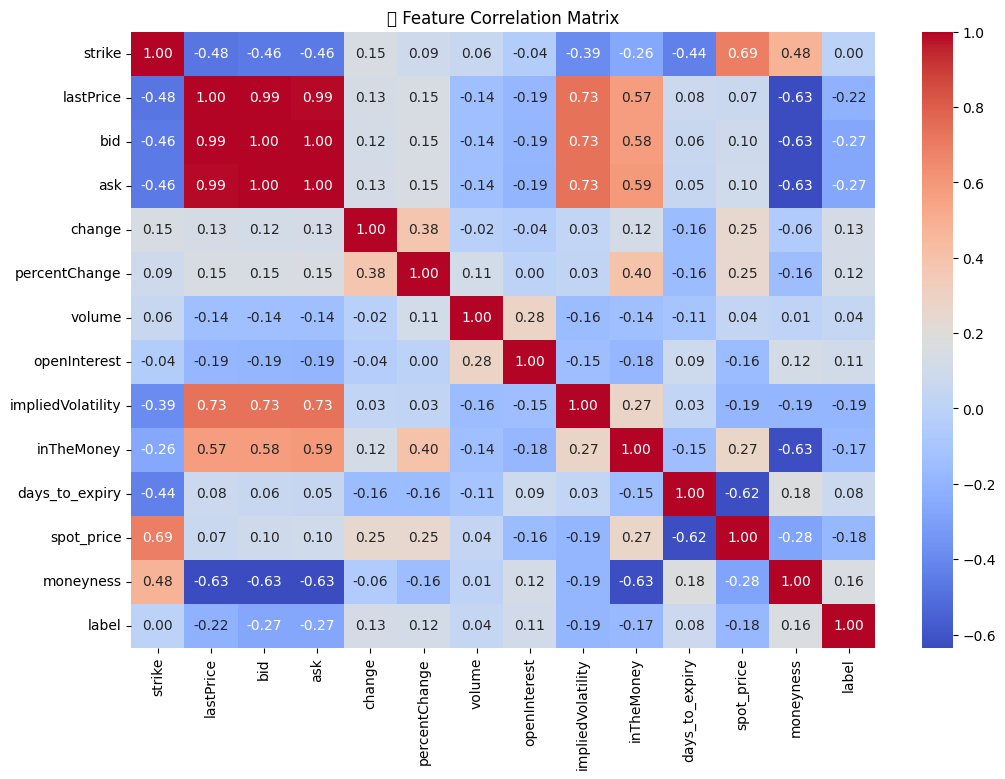

In [6]:
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("📈 Feature Correlation Matrix")
plt.show()


In [7]:
# Feature 1: Bid-Ask Spread
df["bid_ask_spread"] = df["ask"] - df["bid"]

# Feature 2: Mid Price
df["mid_price"] = (df["ask"] + df["bid"]) / 2

# Feature 3: Price Distance from Strike (absolute)
df["spot_strike_diff"] = np.abs(df["spot_price"] - df["strike"])

# Feature 4: Volume/OpenInterest Ratio
df["volume_oi_ratio"] = df["volume"] / (df["openInterest"] + 1)  # +1 to avoid division by zero

# Feature 5: Time Value Proxy
df["time_value"] = df["lastPrice"] - df["moneyness"] * df["spot_price"]


In [8]:
import numpy as np

# Feature 1: Bid-Ask Spread
df["bid_ask_spread"] = df["ask"] - df["bid"]

# Feature 2: Mid Price
df["mid_price"] = (df["ask"] + df["bid"]) / 2

# Feature 3: Price Distance from Strike (absolute)
df["spot_strike_diff"] = np.abs(df["spot_price"] - df["strike"])

# Feature 4: Volume / Open Interest Ratio
df["volume_oi_ratio"] = df["volume"] / (df["openInterest"] + 1)  # +1 to avoid division by zero

# Feature 5: Time Value Proxy (approximation)
df["time_value"] = df["lastPrice"] - df["moneyness"] * df["spot_price"]

print("✅ New features added:", df.columns[-5:].tolist())



✅ New features added: ['bid_ask_spread', 'mid_price', 'spot_strike_diff', 'volume_oi_ratio', 'time_value']


In [9]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Keep only numeric columns and drop non-feature ones
X_all = df.select_dtypes(include=[np.number]).drop(columns=["label"])
y_all = df["label"]

# Scale
scaler = StandardScaler()
X_scaled_all = scaler.fit_transform(X_all)

# SMOTE
smote = SMOTE(random_state=42)
X_resampled_all, y_resampled_all = smote.fit_resample(X_scaled_all, y_all)

print("✅ Data ready — shape:", X_resampled_all.shape)


✅ Data ready — shape: (2314, 17)


In [10]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import VarianceThreshold

# 📥 Step 1: Extract numeric features
X_numeric = df.select_dtypes(include=[np.number]).copy()

# 🎯 Step 2: Extract target
y = df["label"]
X_numeric = X_numeric.drop(columns=["label"], errors="ignore")  # Just in case label is in X

# ⚖️ Step 3: Apply SMOTE on numeric data
smote = SMOTE(random_state=42)
X_resampled_all, y_resampled_all = smote.fit_resample(X_numeric, y)
print("✅ Shape after SMOTE:", X_resampled_all.shape)

# 🚿 Step 4: Apply Variance Threshold
X_resampled_df = pd.DataFrame(X_resampled_all, columns=X_numeric.columns)
selector = VarianceThreshold(threshold=0.01)
X_filtered_all = selector.fit_transform(X_resampled_df)

# 🏷️ Get selected feature names
selected_features = X_resampled_df.columns[selector.get_support()]
print("🔍 Features retained:", selected_features.tolist())
print("✅ Final shape for training:", X_filtered_all.shape)


✅ Shape after SMOTE: (2314, 17)
🔍 Features retained: ['strike', 'lastPrice', 'bid', 'ask', 'change', 'percentChange', 'volume', 'openInterest', 'impliedVolatility', 'days_to_expiry', 'spot_price', 'moneyness', 'bid_ask_spread', 'mid_price', 'spot_strike_diff', 'volume_oi_ratio', 'time_value']
✅ Final shape for training: (2314, 17)


In [11]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV

# 📌 1. Define parameter grid (tight for testing)
param_dist = {
    'n_estimators': [100],
    'learning_rate': [0.05],
    'max_depth': [5, 7],
    'num_leaves': [15, 31],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# 📌 2. Initialize model
lgb_model = LGBMClassifier(random_state=42)

# 📌 3. Run Randomized Search
random_search = RandomizedSearchCV(
    lgb_model,
    param_distributions=param_dist,
    n_iter=4,
    scoring='roc_auc',
    cv=2,
    verbose=1,
    n_jobs=-1
)

# 📌 4. Fit model on filtered features
random_search.fit(X_filtered_all, y_resampled_all)

# ✅ 5. Save best model
best_lgb_all = random_search.best_estimator_
print("✅ Best Params:", random_search.best_params_)


Fitting 2 folds for each of 4 candidates, totalling 8 fits
[LightGBM] [Info] Number of positive: 1157, number of negative: 1157
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000840 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3874
[LightGBM] [Info] Number of data points in the train set: 2314, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Split the filtered dataset
X_train, X_test, y_train, y_test = train_test_split(X_filtered_all, y_resampled_all, test_size=0.2, random_state=42)

# Train best model on training portion
best_lgb_all.fit(X_train, y_train)

# Predict on test set
y_pred = best_lgb_all.predict(X_test)
y_proba = best_lgb_all.predict_proba(X_test)[:, 1]

# Evaluation
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))


[LightGBM] [Info] Number of positive: 919, number of negative: 932
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000436 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3862
[LightGBM] [Info] Number of data points in the train set: 1851, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.496488 -> initscore=-0.014047
[LightGBM] [Info] Start training from score -0.014047
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

C:\Users\msuma\Desktop\options-trading-bot\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\msuma\Desktop\options-trading-bot\venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
